# SRP — Sequential Residual Predictor (v2)
## Key Changes from v1:
- **NO CLS token** - each weak learner makes its own prediction
- **NO diversity regularization** - removed diversity loss
- **Weighted losses** - earlier predictors get higher weights (linearly decreasing)
- **Causal attention** - first learner only sees itself, second sees first+itself, etc.

In [3]:
# Install dependencies
import sys
sys.path.insert(0, '/content/')

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
import torch.nn as nn
print('Setup complete.')

Setup complete.


In [4]:
# Import local modules
import importlib
import weak_learners
import srp_model_v2
import train_v2
from xgboost import XGBRegressor
import weight_schemes

importlib.reload(weak_learners)
importlib.reload(srp_model_v2)
importlib.reload(train_v2)
importlib.reload(weight_schemes)

from weak_learners import WeakLearnerEnsemble
from srp_model_v2 import SRPModel
from train_v2 import train
from weight_schemes import WeightScheme

## 1. Load Dataset

In [5]:
TASK = 'regression'   # 'regression' or 'classification'

if TASK == 'regression':
    data = fetch_california_housing()
    X, y = data.data, data.target.astype(np.float32)
else:
    data = load_wine()
    X, y = data.data.astype(np.float32), data.target

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

from preprocessing import Preprocessor

# Choose method
preprocessor = Preprocessor(method='rankgauss')  # or 'quantile', 'robust', etc.

# Fit and transform
X_scaled = preprocessor.fit_transform(X_tr)
X_val_scaled = preprocessor.transform(X_val)

# Convert to float32 tensors (preprocessor may return float64)
X_tr  = torch.tensor(X_scaled, dtype=torch.float32)
X_val = torch.tensor(X_val_scaled, dtype=torch.float32)
y_tr  = torch.tensor(y_tr, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=  
                     torch.float32)

print(f'Train: {X_tr.shape}, Val: {X_val.shape}')

Train: torch.Size([16512, 8]), Val: torch.Size([4128, 8])


## 2. Build & Train Model

In [6]:
INPUT_DIM   = X_tr.shape[1]
NUM_LEARNERS = 8
HIDDEN_DIM   = 16      # 4-16
EMBED_DIM    = 32     # output dim of each weak learner
DEPTH        = 2      # 1 or 2
OUTPUT_DIM   = 1 if TASK == 'regression' else len(np.unique(y_tr.numpy()))

model = SRPModel(
    input_dim=INPUT_DIM,
    num_learners=NUM_LEARNERS,
    hidden_dim=HIDDEN_DIM,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=2,
    output_dim=OUTPUT_DIM,
    task=TASK
)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Model parameters: 34,561


In [7]:
# Train with weighted losses (default: exponential - later predictors get higher weights)
# You can change weight_scheme to 'linear' or 'uniform' to try different schemes
history = train(
    model, X_tr, y_tr, X_val, y_val,
    epochs=100,
    lr=1e-3,
    batch_size=64,
    l1_lambda=1e-4,
    l2_lambda=1e-4,
    weight_scheme='linear'  # or 'linear', 'uniform'
)

Epoch  10 | train_loss=0.2947 | val_loss=0.3126
Epoch  20 | train_loss=0.2552 | val_loss=0.2945
Epoch  30 | train_loss=0.2366 | val_loss=0.2991
Epoch  40 | train_loss=0.2263 | val_loss=0.3012
Epoch  50 | train_loss=0.2096 | val_loss=0.2796
Epoch  60 | train_loss=0.2014 | val_loss=0.2905
Epoch  70 | train_loss=0.1984 | val_loss=0.2865
Epoch  80 | train_loss=0.1912 | val_loss=0.3048
Epoch  90 | train_loss=0.1913 | val_loss=0.2896
Epoch 100 | train_loss=0.1823 | val_loss=0.2867


## 3. Training Curves

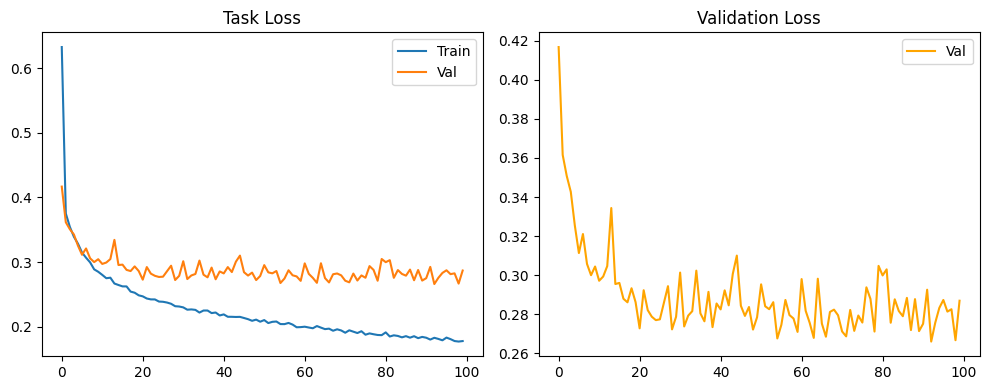

In [18]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title('Task Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_loss'], label='Val', color='orange')
plt.title('Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 4. Understanding Weighted Loss Assignment

The key idea: **Earlier predictors get higher weights** because under causal attention:
- Predictor 1 only sees itself → should be trusted more
- Predictor 2 sees 1+2 → has more context but may overfit to predictor 1's view
- Predictor K sees all → has most context but may be redundant

Weights decrease linearly: w_i = (K - i + 1) / sum(1...K)

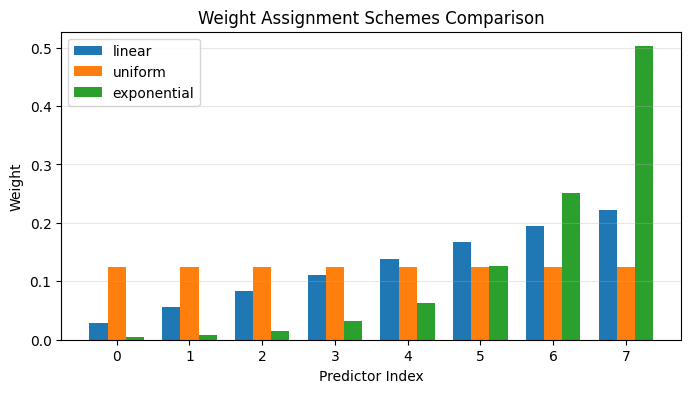

Default exponential weights: [0.004 0.008 0.016 0.031 0.063 0.125 0.251 0.502]


In [19]:
# Demonstrate weight assignment using WeightScheme
K = 8

plt.figure(figsize=(8, 4))
schemes = ['linear', 'uniform', 'exponential']
for scheme in schemes:
    ws = WeightScheme(method=scheme)
    weights = ws.get_weights(K).numpy()
    plt.bar(np.arange(K) + (schemes.index(scheme)-1)*0.25, weights, width=0.25, label=scheme)

plt.xlabel('Predictor Index')
plt.ylabel('Weight')
plt.title('Weight Assignment Schemes Comparison')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Show default exponential weights
ws_default = WeightScheme(method='exponential')
print('Default exponential weights:', np.round(ws_default.get_weights(K).numpy(), 3))


## 5. Attention Weights Visualization

Each row shows what each predictor can attend to:
- Row 1: only column 1 (self)
- Row 2: columns 1,2
- Row i: columns 1 through i

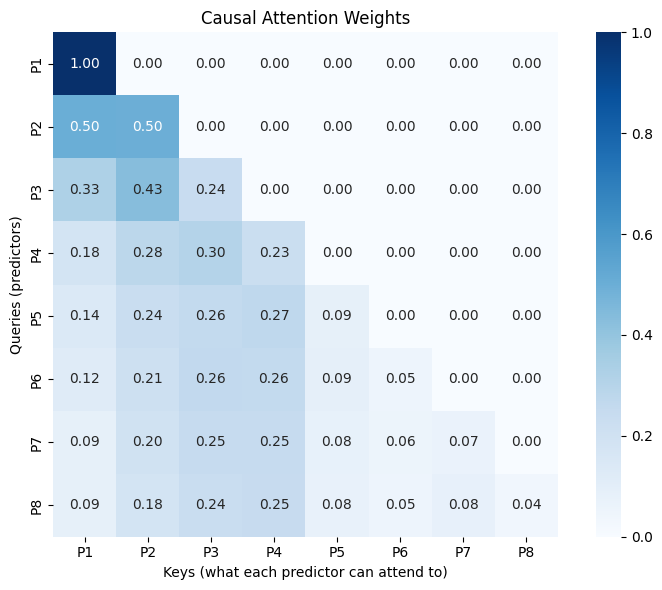

In [20]:
model.eval()
with torch.no_grad():
    predictions, features, attn_weights = model(X_val[:100])

# attn_weights: (B, K, K) - averaged over heads
avg_attn = attn_weights.mean(dim=0).cpu().numpy()

labels = [f'P{i}' for i in range(1, NUM_LEARNERS+1)]

plt.figure(figsize=(8, 6))
sns.heatmap(avg_attn, xticklabels=labels, yticklabels=labels,
            annot=True, fmt='.2f', cmap='Blues', square=True)
plt.title('Causal Attention Weights')
plt.xlabel('Keys (what each predictor can attend to)')
plt.ylabel('Queries (predictors)')
plt.tight_layout()
plt.show()

## 6. Individual Predictor Losses

Compare MSE loss for each predictor's output:

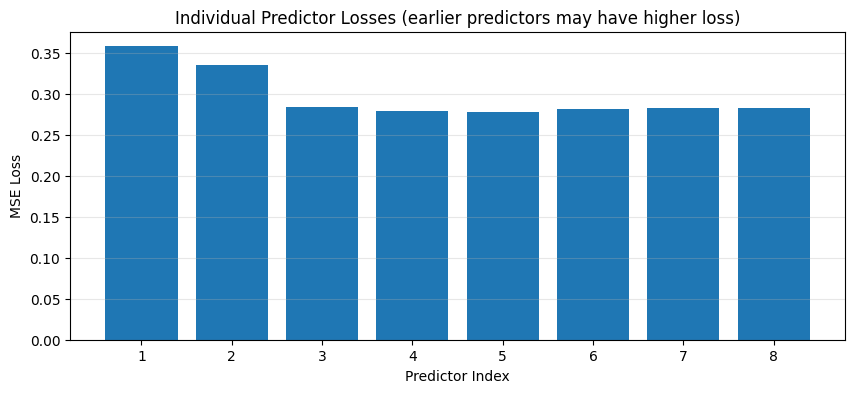

Individual losses: [0.3583 0.3358 0.2836 0.2798 0.2781 0.2821 0.2829 0.283 ]


In [21]:
model.eval()
with torch.no_grad():
    predictions, _, _ = model(X_val)

mse_per_predictor = ((predictions - y_val.unsqueeze(1))**2).mean(dim=0)

plt.figure(figsize=(10, 4))
plt.bar(range(1, NUM_LEARNERS+1), mse_per_predictor.numpy())
plt.xlabel('Predictor Index')
plt.ylabel('MSE Loss')
plt.title('Individual Predictor Losses (earlier predictors may have higher loss)')
plt.xticks(range(1, NUM_LEARNERS+1))
plt.grid(axis='y', alpha=0.3)
plt.show()

print('Individual losses:', np.round(mse_per_predictor.numpy(), 4))

## 7. Final Prediction vs Actual

The final prediction comes from the last predictor (has seen all previous):

=== Final Inference Performance ===
Mean Squared Error (MSE):       0.2777
Root Mean Squared Error (RMSE): 0.5270
Mean Absolute Error (MAE):      0.3513
R-squared (R2) Score:           0.7880 (Closer to 1.0 is better!)
Final validation MSE: 0.2777


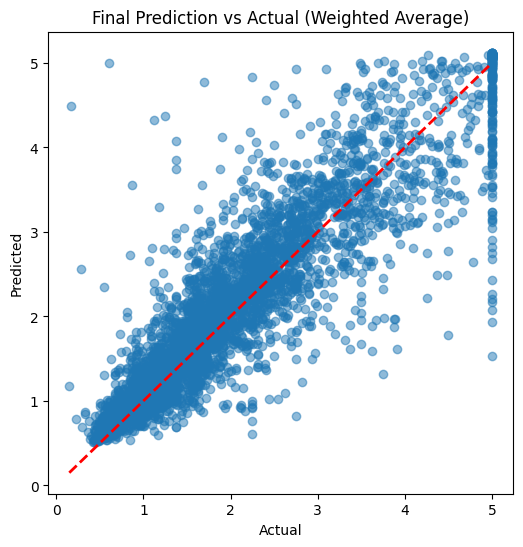

In [22]:

from sklearn.metrics import mean_absolute_error, r2_score


# Use the predict method which returns weighted average
final_pred = model.predict(X_val)
final_mse = ((final_pred - y_val)**2).mean().item()

y_true = y_val.cpu().numpy()
y_pred = final_pred.cpu().numpy()

# 3. Calculate metrics
rmse = np.sqrt(final_mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("=== Final Inference Performance ===")
print(f"Mean Squared Error (MSE):       {final_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"R-squared (R2) Score:           {r2:.4f} (Closer to 1.0 is better!)")

print(f'Final validation MSE: {final_mse:.4f}')

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_val.numpy(), final_pred.numpy(), alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Final Prediction vs Actual (Weighted Average)')
plt.show()

## 7.1 XGBoost Comparison

Train XGBoost on the same dataset and compare final validation predictions to the SRP model.

=== XGBoost Inference Performance ===
Mean Squared Error (MSE):       0.2616
Root Mean Squared Error (RMSE): 0.5114
Mean Absolute Error (MAE):      0.3494
R-squared (R2) Score:           0.8004 (Closer to 1.0 is better!)

=== Model Comparison ===
SRP     MSE: 0.2777, RMSE: 0.5270, MAE: 0.3513, R2: 0.7880
XGBoost MSE: 0.2616, RMSE: 0.5114, MAE: 0.3494, R2: 0.8004


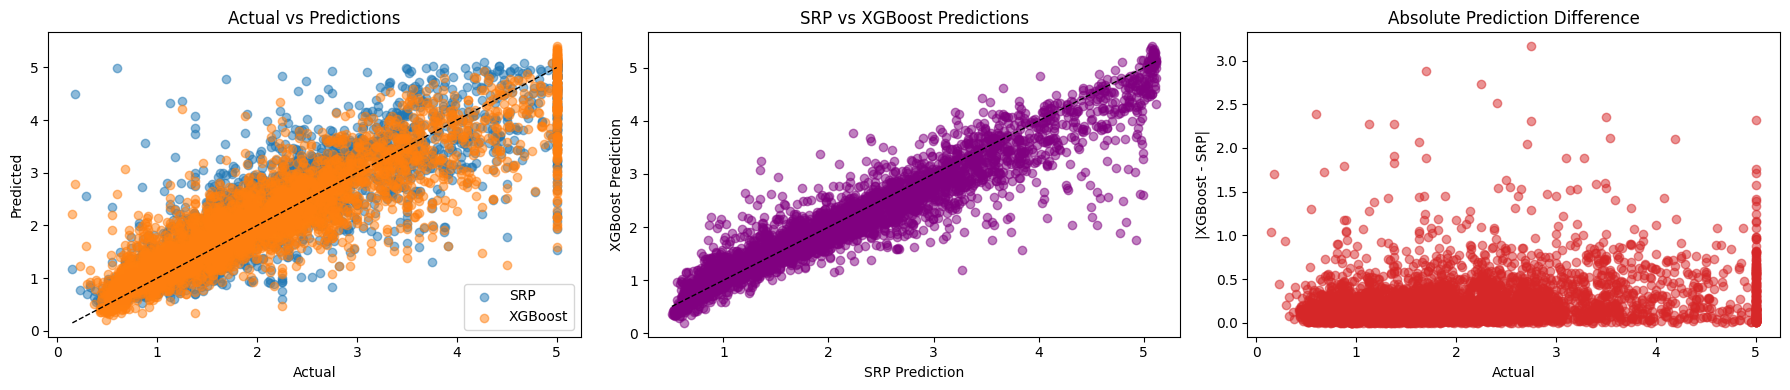

In [23]:
try:
    from xgboost import XGBRegressor
except ImportError:
    !pip install -q xgboost
    from xgboost import XGBRegressor

X_train_np = X_tr.cpu().numpy() if hasattr(X_tr, 'cpu') else X_tr
y_train_np = y_tr.cpu().numpy() if hasattr(y_tr, 'cpu') else y_tr
X_val_np = X_val.cpu().numpy() if hasattr(X_val, 'cpu') else X_val
y_val_np = y_val.cpu().numpy() if hasattr(y_val, 'cpu') else y_val

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_np, y_train_np)

xgb_pred = xgb_model.predict(X_val_np)
xgb_mse = mean_squared_error(y_val_np, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_val_np, xgb_pred)
xgb_r2 = r2_score(y_val_np, xgb_pred)

srp_pred_np = final_pred.cpu().numpy() if hasattr(final_pred, 'cpu') else final_pred
srp_mse = mean_squared_error(y_val_np, srp_pred_np)
srp_rmse = np.sqrt(srp_mse)
srp_mae = mean_absolute_error(y_val_np, srp_pred_np)
srp_r2 = r2_score(y_val_np, srp_pred_np)

print('=== XGBoost Inference Performance ===')
print(f'Mean Squared Error (MSE):       {xgb_mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {xgb_rmse:.4f}')
print(f'Mean Absolute Error (MAE):      {xgb_mae:.4f}')
print(f'R-squared (R2) Score:           {xgb_r2:.4f} (Closer to 1.0 is better!)')

print('')
print('=== Model Comparison ===')
print(f'SRP     MSE: {srp_mse:.4f}, RMSE: {srp_rmse:.4f}, MAE: {srp_mae:.4f}, R2: {srp_r2:.4f}')
print(f'XGBoost MSE: {xgb_mse:.4f}, RMSE: {xgb_rmse:.4f}, MAE: {xgb_mae:.4f}, R2: {xgb_r2:.4f}')

prediction_diff = xgb_pred - srp_pred_np
abs_diff = np.abs(prediction_diff)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].scatter(y_val_np, srp_pred_np, alpha=0.5, label='SRP')
axes[0].scatter(y_val_np, xgb_pred, alpha=0.5, label='XGBoost')
axes[0].plot([y_val_np.min(), y_val_np.max()], [y_val_np.min(), y_val_np.max()], 'k--', lw=1)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predictions')
axes[0].legend()

axes[1].scatter(srp_pred_np, xgb_pred, alpha=0.5, color='purple')
axes[1].plot([srp_pred_np.min(), srp_pred_np.max()], [srp_pred_np.min(), srp_pred_np.max()], 'k--', lw=1)
axes[1].set_xlabel('SRP Prediction')
axes[1].set_ylabel('XGBoost Prediction')
axes[1].set_title('SRP vs XGBoost Predictions')

axes[2].scatter(y_val_np, abs_diff, alpha=0.5, color='tab:red')
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('|XGBoost - SRP|')
axes[2].set_title('Absolute Prediction Difference')

plt.tight_layout()
plt.show()

## 8. Grid Search for Hyperparameter Tuning

Find optimal hyperparameters for the SRP model. Note: Parameters should be retuned for different datasets.

In [24]:
import itertools
from sklearn.metrics import mean_squared_error, r2_score

# Define hyperparameter grid
param_grid = {
    'num_learners': [4, 8, 12],
    'hidden_dim': [4, 8, 16],
    'embed_dim': [16, 32],
    'depth': [1, 2],
    'weight_scheme': ['linear', 'exponential']  # linear gives more weight to earlier predictors
}

# Generate all combinations
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Total combinations to test: {len(combinations)}")

# Store results
grid_results = []
best_mse = float('inf')
best_params = None

# Run grid search (using fewer epochs for speed)
for i, params in enumerate(combinations):
    print(f"\n[{i+1}/{len(combinations)}] Testing: {params}")
    
    # Build model with current params
    model_gs = SRPModel(
        input_dim=INPUT_DIM,
        num_learners=params['num_learners'],
        hidden_dim=params['hidden_dim'],
        embed_dim=params['embed_dim'],
        depth=params['depth'],
        num_heads=2,
        output_dim=OUTPUT_DIM,
        task=TASK
    )
    
    # Train
    history_gs = train(
        model_gs, X_tr, y_tr, X_val, y_val,
        epochs=30,  # Fewer epochs for grid search
        lr=1e-3,
        batch_size=64,
        l1_lambda=1e-4,
        l2_lambda=1e-4,
        weight_scheme=params['weight_scheme']
    )
    
    # Evaluate
    model_gs.eval()
    with torch.no_grad():
        preds, _, _ = model_gs(X_val)
        final_pred = preds[:, -1]
        mse = mean_squared_error(y_val.numpy(), final_pred.numpy())
        r2 = r2_score(y_val.numpy(), final_pred.numpy())
    
    result = {**params, 'mse': mse, 'r2': r2, 'final_val_loss': history_gs['val_loss'][-1]}
    grid_results.append(result)
    
    if mse < best_mse:
        best_mse = mse
        best_params = params.copy()
    
    print(f"  MSE: {mse:.4f}, R2: {r2:.4f}")

# Convert to DataFrame
grid_results_df = pd.DataFrame(grid_results)
print("\n=== Grid Search Results ===")
print(grid_results_df.sort_values('mse').head(10))

print(f"\n=== Best Parameters ===")
print(best_params)
print(f"Best MSE: {best_mse:.4f}")

# Save best params for later use
BEST_PARAMS = best_params

Total combinations to test: 72

[1/72] Testing: {'num_learners': 4, 'hidden_dim': 4, 'embed_dim': 16, 'depth': 1, 'weight_scheme': 'linear'}
Epoch  10 | train_loss=0.3622 | val_loss=0.3556
Epoch  20 | train_loss=0.3449 | val_loss=0.3450
Epoch  30 | train_loss=0.3302 | val_loss=0.3297
  MSE: 0.3173, R2: 0.7579

[2/72] Testing: {'num_learners': 4, 'hidden_dim': 4, 'embed_dim': 16, 'depth': 1, 'weight_scheme': 'exponential'}
Epoch  10 | train_loss=0.3500 | val_loss=0.3628
Epoch  20 | train_loss=0.3323 | val_loss=0.3306
Epoch  30 | train_loss=0.3238 | val_loss=0.3285
  MSE: 0.3168, R2: 0.7582

[3/72] Testing: {'num_learners': 4, 'hidden_dim': 4, 'embed_dim': 16, 'depth': 2, 'weight_scheme': 'linear'}
Epoch  10 | train_loss=0.3535 | val_loss=0.3415
Epoch  20 | train_loss=0.3240 | val_loss=0.3295
Epoch  30 | train_loss=0.3123 | val_loss=0.3095
  MSE: 0.2965, R2: 0.7737

[4/72] Testing: {'num_learners': 4, 'hidden_dim': 4, 'embed_dim': 16, 'depth': 2, 'weight_scheme': 'exponential'}
Epoch  10

KeyboardInterrupt: 

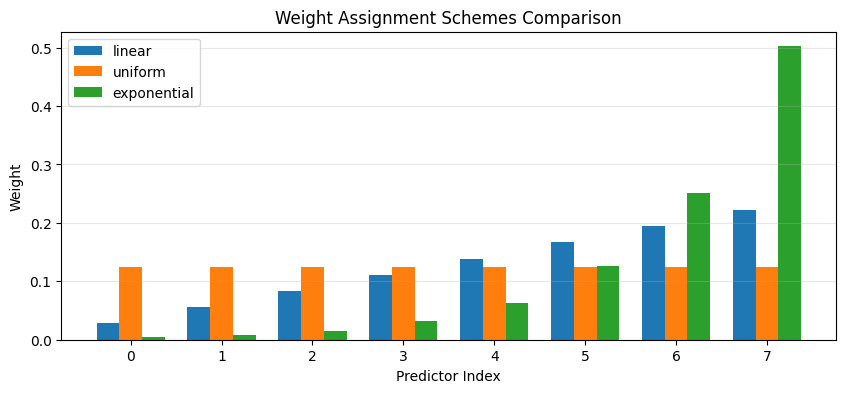

In [ ]:
# Compare schemes using WeightScheme
K = 8
schemes = ['linear', 'uniform', 'exponential']

plt.figure(figsize=(10, 4))
for scheme in schemes:
    ws = WeightScheme(method=scheme)
    w = ws.get_weights(K).numpy()
    plt.bar(np.arange(K) + (schemes.index(scheme)-1)*0.25, w, width=0.25, label=scheme)

plt.xlabel('Predictor Index')
plt.ylabel('Weight')
plt.title('Weight Assignment Schemes Comparison')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Store for later use
WEIGHT_SCHEMES = ['linear', 'uniform', 'exponential']

In [ ]:
import pandas as pd

In [ ]:
# Run weight scheme comparison using the new WeightScheme parameter
weight_results = []
print('Running weight scheme comparison...')

for scheme in WEIGHT_SCHEMES:
    print(f'Testing {scheme} weight scheme...')
    
    model_ws = SRPModel(
        input_dim=INPUT_DIM,
        num_learners=NUM_LEARNERS,
        hidden_dim=HIDDEN_DIM,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=2,
        output_dim=OUTPUT_DIM,
        task=TASK
    )
    
    history_ws = train(
        model_ws, X_tr, y_tr, X_val, y_val,
        epochs=50, lr=1e-3, batch_size=64,
        l1_lambda=1e-4, l2_lambda=1e-4,
        weight_scheme=scheme
    )
    
    # Use predict method for weighted average
    final_pred = model_ws.predict(X_val, weight_scheme=scheme)
    mse = mean_squared_error(y_val.numpy(), final_pred.numpy())
    r2 = r2_score(y_val.numpy(), final_pred.numpy())
    
    weight_results.append({
        'scheme': scheme,
        'final_val_loss': history_ws['val_loss'][-1],
        'mse': mse,
        'r2': r2
    })
    print(f'  Val Loss: {history_ws["val_loss"][-1]:.4f}, MSE: {mse:.4f}, R2: {r2:.4f}')

weight_results_df = pd.DataFrame(weight_results)
print('\n=== Weight Scheme Comparison Results ===')
print(weight_results_df.sort_values('mse'))

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
weight_results_df.plot(x='scheme', y='mse', ax=axes[0], kind='bar', legend=False, color='blue')
axes[0].set_title('MSE by Weight Scheme')

weight_results_df.plot(x='scheme', y='r2', ax=axes[1], kind='bar', legend=False, color='green')
axes[1].set_title('R² by Weight Scheme')

weight_results_df.plot(x='scheme', y='final_val_loss', ax=axes[2], kind='bar', legend=False, color='orange')
axes[2].set_title('Final Val Loss by Weight Scheme')

plt.tight_layout()
plt.show()

# Summary
print('\n=== FINAL SUMMARY ===')
print('\nBest preprocessing method:')
print(preprocessing_results.sort_values('mse').iloc[0])
print('\nBest weight scheme:')
print(weight_results_df.sort_values('mse').iloc[0])